**Parte V** - *¿qué tan bien describe ese modelo la realidad?*

**Bloque A:** Ciclo económico mediante el filtro Hodrick-Prescot

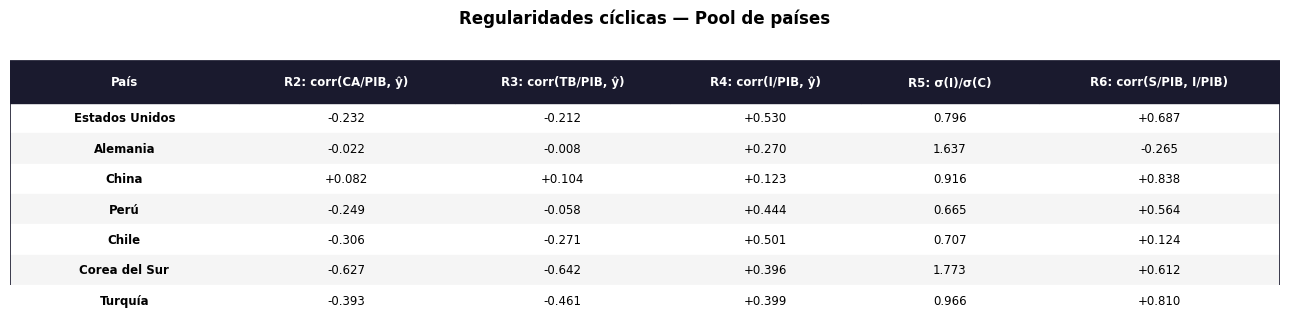

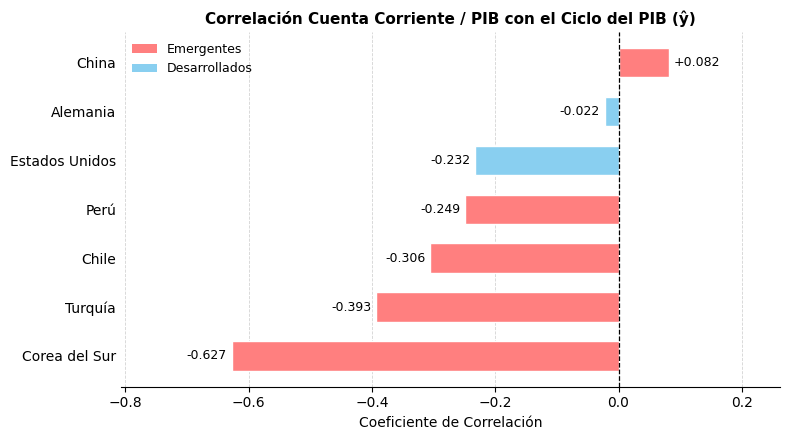

In [ ]:
# ----------------------------------------------------------------------------
# |                    BLOQUE A                                               |
# ----------------------------------------------------------------------------


#     Instalacion ( correr solo una vez por sesion )
! pip install wbgapi statsmodels -q


#  Librerías
import wbgapi as wb
import pandas as pd
import numpy as np
from statsmodels.tsa.filters.hp_filter import hpfilter
import matplotlib.pyplot as plt
import matplotlib as mpl

#-------------------------------------------------------------------------------


#  Diccionario de indicadores WDI
   # Claves : codigos WDI (lo que la API necesita para descargar )
   # Valores : nombres en codigo (lo que usaran en todo su analisis )
indicators = {
'NY.GDP.MKTP.KD': 'gdp_real', # PIB real
'BN.CAB.XOKA.GD.ZS': 'ca_gdp', # Cuenta corriente / PIB
'NE.RSB.GNFS.ZS': 'tb_gdp', # Balanza comercial / PIB
'NE.GDI.TOTL.ZS': 'inv_gdp', # Inversion bruta / PIB
'NY.GNS.ICTR.ZS': 'sav_gdp', # Ahorro bruto / PIB
'NE.CON.TOTL.ZS': 'cons_gdp', # Consumo total / PIB
}

#  Pool de Países
## Se definen los objetos a iterar

countries = {
    'USA': 'Estados Unidos',
    'DEU': 'Alemania',
    'CHN': 'China',
    'PER': 'Perú',
    'CHL': 'Chile',
    'KOR': 'Corea del Sur',
    'TUR': 'Turquía',
}

#-------------------------------------------------------------------------------

# Inicializamos el diccionario results antes del bucle
results = {}  #llamamos los resultados

#Realizamos un bucle o iteración para el código visto en el PS01
for code, name in countries.items():

    ## Descarga de datos para el pool
    raw = wb.data.DataFrame(
    list(indicators.keys()), # lista de codigos WDI a descargar
    economy = code, # <<< CAMBIAR AQUI para otro pais
    time = range(1990,2024) # rango de anios
    )

    # Transponer : el output de wbgapi tiene indicadores como filas y
    # años como columnas ; lo invertimos para que cada fila sea un año
    df = raw.T
    df.columns = [indicators[c] for c in raw.index]
    df.index = [int(str(i).replace ('YR','')) for i in df.index]
    df = df.sort_index().astype(float)

    # == Filtro HP: extraer el ciclo del PIB

    # Se aplica al logaritmo del PIB real ( lambda =6.25 para datos anuales )
    df_clean = df['gdp_real'].dropna()
    cycle, trend = hpfilter( x = np.log(df_clean) , lamb=6.25)
    df['gdp_cycle'] = cycle.reindex(df.index)

    # == Estadisticos ciclicos (R2 a R6)

    corr_CA = df['gdp_cycle'].corr(df['ca_gdp'])
    corr_TB = df['gdp_cycle'].corr(df['tb_gdp'])
    corr_I = df['gdp_cycle'].corr(df['inv_gdp'])
    vol_ratio = df['inv_gdp'].std()/df ['cons_gdp'].std()
    corr_SI = df['sav_gdp'].corr(df ['inv_gdp'])


#   Acumula los resultados
    results[code] = {
        'País':              name,
        'R2: corr(CA/PIB, ŷ)':    corr_CA,
        'R3: corr(TB/PIB, ŷ)':    corr_TB,
        'R4: corr(I/PIB, ŷ)':     corr_I,
        'R5: σ(I)/σ(C)':          vol_ratio,
        'R6: corr(S/PIB, I/PIB)': corr_SI,
    }


# ------------------------------------------------------------------------------

       # -----------------------------------------------  #
       # |         Diseñando la tabla maestra           | #
       # -----------------------------------------------  #

#  Tabla consolidad: una fila por país, una columna por estadístico



stat_cols = ['R2: corr(CA/PIB, ŷ)', 'R3: corr(TB/PIB, ŷ)',
             'R4: corr(I/PIB, ŷ)',  'R5: σ(I)/σ(C)',
             'R6: corr(S/PIB, I/PIB)']

# Construcción de las filas de la tabla
table_rows = []
for code, data in results.items():
    row = [data['País']]
    for col in stat_cols:
        val = data[col]
        fmt = f"{val:.3f}" if col == 'R5: σ(I)/σ(C)' else f"{val:+.3f}"
        row.append(fmt)
    table_rows.append(row)

headers = ['País'] + stat_cols

# Figura
col_widths = [0.18, 0.17, 0.17, 0.15, 0.14, 0.19]  # suma = 1.0
col_x      = [sum(col_widths[:i]) for i in range(len(col_widths))]
DARK, WHITE, GRAY = "#1a1a2e", "#ffffff", "#f5f5f5"

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.axis("off")
fig.suptitle("Regularidades cíclicas — Pool de países", fontsize=12, fontweight="bold")

# Encabezados
for header, x, w in zip(headers, col_x, col_widths):
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (x, 0.78), w, 0.18, transform=ax.transAxes,
        boxstyle="square,pad=0", color=DARK, zorder=2))
    ax.text(x + w/2, 0.87, header, transform=ax.transAxes,
            ha="center", va="center", fontsize=8.5,
            fontweight="bold", color=WHITE, zorder=3)

# Filas
row_h = 0.13
for i, row in enumerate(table_rows):
    y_top = 0.78 - (i + 1) * row_h
    bg = WHITE if i % 2 == 0 else GRAY
    ax.add_patch(mpl.patches.FancyBboxPatch(
        (0, y_top), 1.0, row_h, transform=ax.transAxes,
        boxstyle="square,pad=0", color=bg, zorder=1))
    for j, (cell, x, w) in enumerate(zip(row, col_x, col_widths)):
        ax.text(x + w/2, y_top + row_h/2, cell,
                transform=ax.transAxes, ha="center", va="center",
                fontsize=8.5, color="black",
                fontweight="bold" if j == 0 else "normal")

# Borde exterior
ax.add_patch(mpl.patches.FancyBboxPatch(
    (0, 0.78 - len(table_rows)*row_h), 1.0, 0.18 + len(table_rows)*row_h,
    transform=ax.transAxes, boxstyle="square,pad=0",
    edgecolor=DARK, facecolor="none", linewidth=1.2, zorder=4))

plt.tight_layout()
plt.savefig("tabla_consolidada.png", dpi=150, bbox_inches="tight")
plt.show()


       # -----------------------------------------------  #
       # |       Gráfico de barras horizontales        | #
       # -----------------------------------------------  #

# ── Clasificación por grupo ──────────────────────────────────────────────────
groups = {
    'USA': 'Desarrollado',
    'DEU': 'Desarrollado',
    'CHN': 'Emergente',
    'PER': 'Emergente',
    'CHL': 'Emergente',
    'KOR': 'Emergente',
    'TUR': 'Emergente',
}

COLOR_DEV = "#89CFF0"   # azul claro → desarrollados
COLOR_EMG = "#FF7F7F"   # rojo/salmón → emergentes

# Construir series desde results
codes  = list(results.keys())
names  = [results[c]['País']    for c in codes] # Corrected 'país' to 'País'
values = [results[c]['R2: corr(CA/PIB, ŷ)'] for c in codes] # Corrected 'corr_CA' to the correct key
colors = [COLOR_DEV if groups[c] == 'Desarrollado' else COLOR_EMG for c in codes]

# Se ordenan los resultados de menor a mayor
orden  = sorted(range(len(values)), key=lambda i: values[i])
names  = [names[i]  for i in orden]
values = [values[i] for i in orden]
colors = [colors[i] for i in orden]

#  Formando la figura del gráfico
fig, ax = plt.subplots(figsize=(8, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.barh(names, values, color=colors, edgecolor="white", height=0.6)

# Línea vertical punteada
ax.xaxis.grid(True, linestyle="--", linewidth=0.6, color="lightgray", zorder=0)
ax.set_axisbelow(True)

# Línea vertical en 0
ax.axvline(0, color="black", linewidth=0.9, linestyle="--")

# Etiquetas con el valor al extremo de cada barra
for bar, val in zip(bars, values):
    offset = 0.008 if val >= 0 else -0.008
    ha     = "left"  if val >= 0 else "right"
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=9, color="black")

# Leyenda del gráfico
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_EMG, label="Emergentes"),
    Patch(facecolor=COLOR_DEV, label="Desarrollados"),
]
ax.legend(handles=legend_elements, frameon=False, fontsize=9, loc="upper left")

# Estética del gráfico
ax.set_xlabel("Coeficiente de Correlación", fontsize=10)
ax.set_title("Correlación Cuenta Corriente / PIB con el Ciclo del PIB (ŷ)",
             fontsize=11, fontweight="bold")
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)  # quita los ticks del eje y
ax.set_xlim(min(values) - 0.18, max(values) + 0.18)

plt.tight_layout()
plt.savefig("correlacion_cuenta_corriente_pbi.png", dpi=150, bbox_inches="tight")
plt.show()